In [100]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

In [101]:
df = pd.read_csv(
    "data/customer_segments.csv"
)
df.head()

,Customer_ID,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region
0,30001,24,9,505714,45856,0.47,0.05,16,10,4.7,Seoul
1,30002,42,2,73314,41320,0.22,0.01,10,4,4.0,Seoul
2,30003,39,10,215402,23642,0.20,0.14,11,14,3.3,Seoul
3,30004,21,4,343927,65800,0.15,0.07,9,3,4.0,Seoul
4,30005,2,19,1633920,70789,0.17,0.05,18,46,4.8,Seoul


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       8000 non-null   int64  
 1   Recency_Days      8000 non-null   int64  
 2   Frequency_90D     8000 non-null   int64  
 3   Monetary_90D      8000 non-null   int64  
 4   Avg_Basket        8000 non-null   int64  
 5   Discount_Ratio    8000 non-null   float64
 6   Return_Ratio      8000 non-null   float64
 7   Web_Visits_30D    8000 non-null   int64  
 8   App_Sessions_30D  8000 non-null   int64  
 9   Review_Score      8000 non-null   float64
 10  Region            8000 non-null   str    
dtypes: float64(3), int64(7), str(1)
memory usage: 687.6 KB


(array([1714., 1963., 1829.,  909.,  468.,  381.,  344.,  179.,   77.,
          23.,   10.,   16.,   13.,   16.,    9.,   15.,    7.,    8.,
           8.,   11.]),
 array([  0.  ,   5.95,  11.9 ,  17.85,  23.8 ,  29.75,  35.7 ,  41.65,
         47.6 ,  53.55,  59.5 ,  65.45,  71.4 ,  77.35,  83.3 ,  89.25,
         95.2 , 101.15, 107.1 , 113.05, 119.  ]),
 <BarContainer object of 20 artists>)

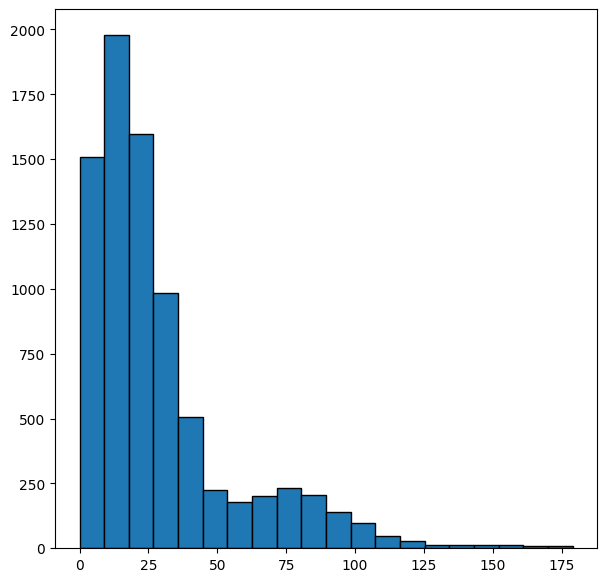

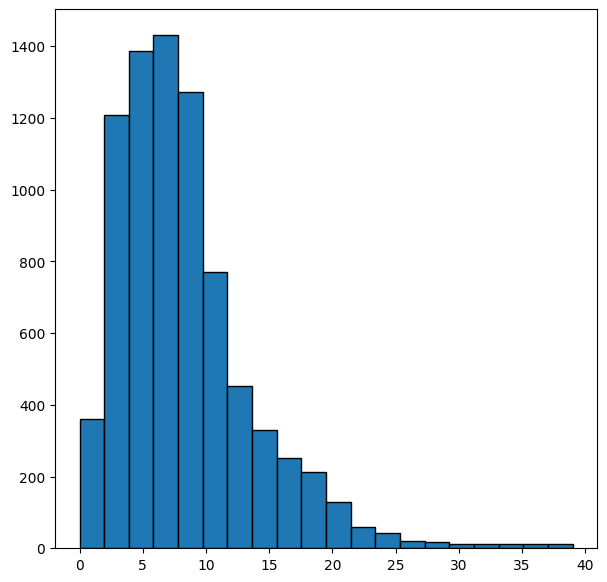

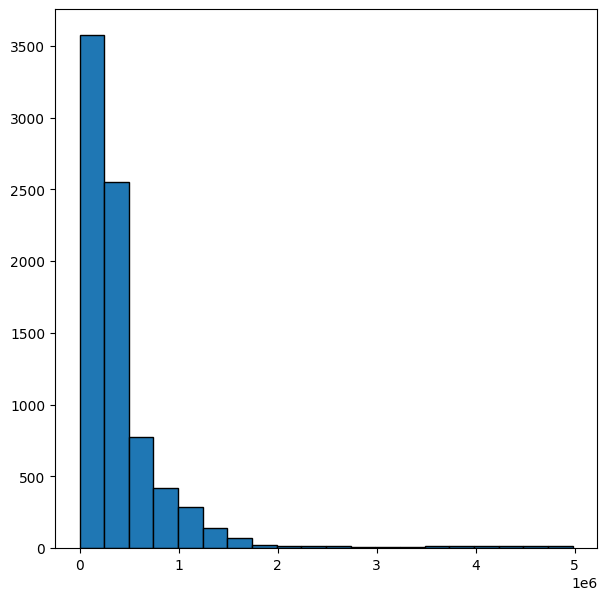

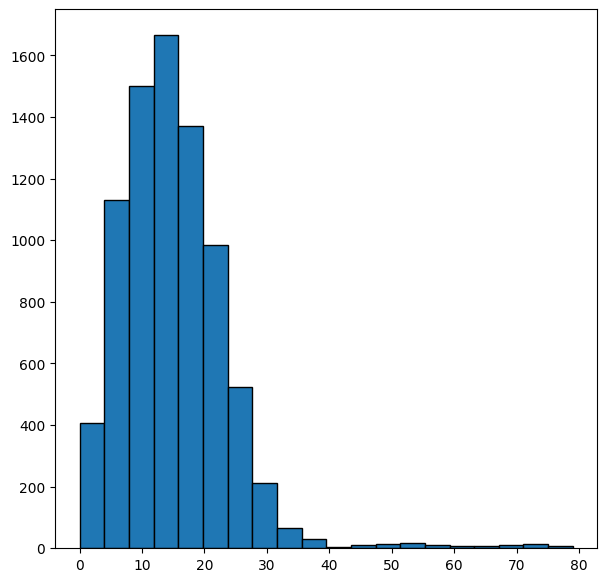

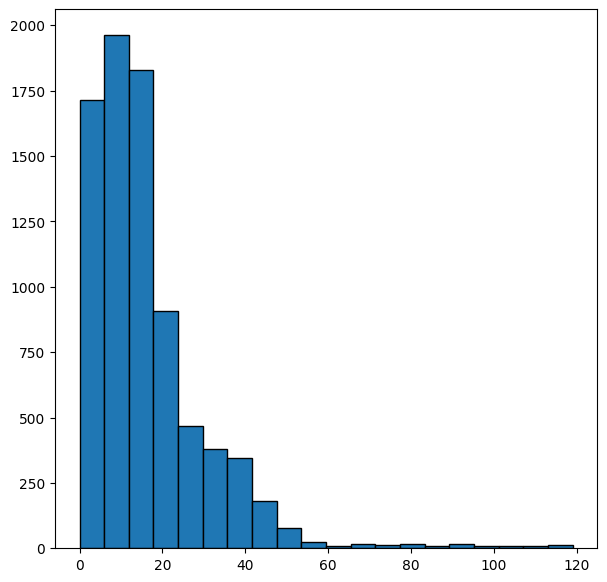

In [103]:
plt.figure(figsize=(7,7))
plt.hist(df["Recency_Days"], bins=20, edgecolor="black")

plt.figure(figsize=(7,7))
plt.hist(df["Frequency_90D"], bins=20, edgecolor="black")

plt.figure(figsize=(7,7))
plt.hist(df["Monetary_90D"], bins=20, edgecolor="black")

plt.figure(figsize=(7,7))
plt.hist(df["Web_Visits_30D"], bins=20, edgecolor="black")

plt.figure(figsize=(7,7))
plt.hist(df["App_Sessions_30D"], bins=20, edgecolor="black")

# 1. 고객 등급 분류

 1   Recency_Days      8000 non-null   int64  
 2   Frequency_90D     8000 non-null   int64  
 3   Monetary_90D      8000 non-null   int64  
 4   Avg_Basket        8000 non-null   int64  
 5   Discount_Ratio    8000 non-null   float64
 6   Return_Ratio      8000 non-null   float64
 7   Web_Visits_30D    8000 non-null   int64  
 8   App_Sessions_30D  8000 non-null   int64  
 9   Review_Score      8000 non-null   float64
 10  Region            8000 non-null   str    

In [104]:
df_cluster = df[['Recency_Days', 'Frequency_90D', 'Monetary_90D', 'Web_Visits_30D', 'App_Sessions_30D', 'Review_Score']]

df_cluster

,Recency_Days,Frequency_90D,Monetary_90D,Web_Visits_30D,App_Sessions_30D,Review_Score
0,24,9,505714,16,10,4.7
1,42,2,73314,10,4,4.0
2,39,10,215402,11,14,3.3
3,21,4,343927,9,3,4.0
4,2,19,1633920,18,46,4.8
...,...,...,...,...,...,...
7995,31,9,291973,20,7,3.8
7996,6,17,1216169,25,42,4.7
7997,77,1,57295,8,6,3.3
7998,13,5,205572,17,19,4.2


In [105]:
log_column_list = ['Frequency_90D', 'Monetary_90D', 'Web_Visits_30D', 'App_Sessions_30D']
for c in log_column_list:
    df_cluster[c] = np.log1p(df_cluster[c])

df_cluster

,Recency_Days,Frequency_90D,Monetary_90D,Web_Visits_30D,App_Sessions_30D,Review_Score
0,24,2.302585,13.133729,2.833213,2.397895,4.7
1,42,1.098612,11.202521,2.397895,1.609438,4.0
2,39,2.397895,12.280266,2.484907,2.708050,3.3
3,21,1.609438,12.748188,2.302585,1.386294,4.0
4,2,2.995732,14.306493,2.944439,3.850148,4.8
...,...,...,...,...,...,...
7995,31,2.302585,12.584420,3.044522,2.079442,3.8
7996,6,2.890372,14.011217,3.258097,3.761200,4.7
7997,77,0.693147,10.955986,2.197225,1.945910,3.3
7998,13,1.791759,12.233556,2.890372,2.995732,4.2


In [106]:
ss_scaler = StandardScaler()
scaled_data = ss_scaler.fit_transform(df_cluster)

In [107]:
kmeans_model = KMeans(n_clusters=4, random_state=42)
kmeans_model.fit(scaled_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [109]:
kmeans_model.cluster_centers_

array([[-0.45702448,  0.98260405,  0.70053613,  0.75862433,  0.94196206,
         0.56548291],
       [ 0.35432202, -3.19346249, -8.70921279, -0.36777842, -0.54989197,
        -0.18645128],
       [ 1.56063129, -1.25088799, -0.84769606, -1.27468393, -1.30680176,
        -0.45822655],
       [-0.22499723, -0.13410449, -0.02865772, -0.03463372, -0.12684026,
        -0.17845605]])

In [110]:
df_cluster.groupby("isActive").mean()


,Recency_Days,Frequency_90D,Monetary_90D,Web_Visits_30D,App_Sessions_30D,Review_Score
isActive,,,,,,
0,16.161116,2.640029,13.407961,3.067753,3.322678,4.495462
1,38.264151,0.000000,0.000000,2.361841,2.011721,4.069811
2,71.140445,1.225094,11.195875,1.793370,1.345515,3.916500
3,22.427157,1.932689,12.366604,2.571740,2.383359,4.075248


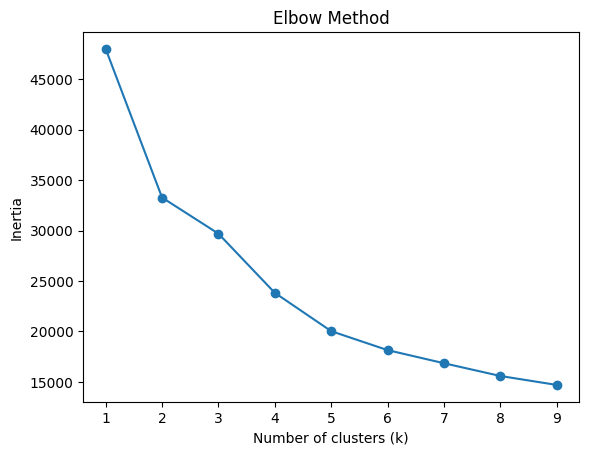

In [111]:
inertia = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [112]:
df_cluster[['Frequency_90D','Monetary_90D']].describe()

,Frequency_90D,Monetary_90D
count,8000.000000,8000.000000
mean,2.017014,12.406660
std,0.631647,1.424633
min,0.000000,0.000000
25%,1.609438,11.919472
50%,2.079442,12.529769
75%,2.397895,13.069491
max,3.688879,15.420937


In [113]:
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_model.fit(scaled_data)

df_cluster["cluster"] = kmeans_model.labels_

In [114]:
df_cluster.groupby("cluster").mean(numeric_only=True)

,Recency_Days,Frequency_90D,Monetary_90D,Web_Visits_30D,App_Sessions_30D,Review_Score,isActive
cluster,,,,,,,
0,92.702020,2.876847,14.411500,3.400107,3.749561,2.598990,0.909091
1,69.872967,1.205086,11.155637,1.789214,1.320333,3.941596,2.004648
2,11.220272,2.603977,13.337541,3.030605,3.282729,4.593418,0.050022
3,38.264151,0.000000,0.000000,2.361841,2.011721,4.069811,1.000000
4,22.139028,1.932585,12.347839,2.566399,2.372861,4.095932,2.979182


In [115]:
kmeans_model.inertia_


20023.83595975268

In [116]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_data, kmeans_model.labels_)

0.2809899914414506

In [122]:
df_cluster['isActive'] = kmeans_model.labels_

df_cluster

,Recency_Days,Frequency_90D,Monetary_90D,Web_Visits_30D,App_Sessions_30D,Review_Score,isActive,cluster,isActive_label
0,24,2.302585,13.133729,2.833213,2.397895,4.7,2,2,Lost VIP
1,42,1.098612,11.202521,2.397895,1.609438,4.0,1,1,Active
2,39,2.397895,12.280266,2.484907,2.708050,3.3,4,4,At-risk
3,21,1.609438,12.748188,2.302585,1.386294,4.0,4,4,At-risk
4,2,2.995732,14.306493,2.944439,3.850148,4.8,2,2,Lost VIP
...,...,...,...,...,...,...,...,...,...
7995,31,2.302585,12.584420,3.044522,2.079442,3.8,4,4,At-risk
7996,6,2.890372,14.011217,3.258097,3.761200,4.7,2,2,Lost VIP
7997,77,0.693147,10.955986,2.197225,1.945910,3.3,1,1,Active
7998,13,1.791759,12.233556,2.890372,2.995732,4.2,4,4,At-risk


In [123]:
grade_map = {
    2: 'Active',
    4: 'Regular',
    3: 'At-risk',
    1: 'Dormant',
    0: 'Lost VIP'
}

df_cluster["isActive_label"] = df_cluster["isActive"].map(grade_map)

In [124]:
df_cluster["cluster"].value_counts()

cluster
4    4179
2    2279
1    1291
0     198
3      53
Name: count, dtype: int64

In [125]:
df_cluster["isActive_label"].value_counts()

isActive_label
Regular     4179
Active      2279
Dormant     1291
Lost VIP     198
At-risk       53
Name: count, dtype: int64

In [127]:
df_cluster["isActive_label"].value_counts(normalize=True)

isActive_label
Regular     0.522375
Active      0.284875
Dormant     0.161375
Lost VIP    0.024750
At-risk     0.006625
Name: proportion, dtype: float64